In [2]:
import pandas as pd

# 加载 Excel 文件
xls = pd.ExcelFile("../data/processed/store_sales_split.xlsx")

# 查看所有 sheet 名称
print(xls.sheet_names)

# 读取第二个 sheet（通常是第一家门店）
df_store_1 = pd.read_excel(xls, sheet_name=xls.sheet_names[1])

['All Stores', 'Store S001', 'Store S002', 'Store S003', 'Store S004', 'Store S005']


In [2]:
df_store_1

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,2024-01-30,S001,P0016,Groceries,North,225,66,0,35.90,5,Snowy,0,40.01,Winter,0,90
15196,2024-01-30,S001,P0017,Toys,North,186,95,0,21.59,5,Snowy,0,18.98,Winter,0,80
15197,2024-01-30,S001,P0018,Groceries,North,130,76,63,52.32,10,Snowy,0,44.80,Winter,0,70
15198,2024-01-30,S001,P0019,Furniture,North,110,54,71,96.80,10,Snowy,0,101.93,Winter,0,61


In [3]:
# 按日期统计总商品数
total_per_day = df_store_1.groupby('Date').size().reset_index(name='Total_Items')

# 按日期统计促销商品数
promo_per_day = df_store_1[df_store_1['Promotion'] == 1].groupby('Date')['Product ID'].count().reset_index(name='Promo_Items')

# 合并两个统计结果
stats = pd.merge(total_per_day, promo_per_day, on='Date', how='left')
stats['Promo_Items'] = stats['Promo_Items'].fillna(0).astype(int)

# 计算占比
stats['Promo_Ratio'] = (stats['Promo_Items'] / stats['Total_Items']).round(4)

# 将统计结果保存为 CSV 文件
stats.to_csv('../data/processed/promo_stats.csv', index=False, encoding='utf-8-sig')

print(stats)

          Date  Total_Items  Promo_Items  Promo_Ratio
0   2022-01-01           20            3         0.15
1   2022-01-02           20            4         0.20
2   2022-01-03           20            7         0.35
3   2022-01-04           20            9         0.45
4   2022-01-05           20           14         0.70
..         ...          ...          ...          ...
755 2024-01-26           20            6         0.30
756 2024-01-27           20           11         0.55
757 2024-01-28           20            7         0.35
758 2024-01-29           20            0         0.00
759 2024-01-30           20            0         0.00

[760 rows x 4 columns]


In [4]:
def mark_promotion_days(df, ratio_col='Promo_Ratio', threshold=0.3):
    """
    根据促销占比阈值标记促销日，并生成标签列。
    
    参数：
    df : pandas.DataFrame
        包含日期和促销占比的原始数据表
    ratio_col : str
        表示促销占比的列名
    threshold : float
        判定为促销日的占比阈值（默认 0.3）
    
    返回：
    pandas.DataFrame
        添加 Is_Promotion_Day 和 Promotion_Day_Label 的新表
    """
    df = df.copy()
    df['Is_Promotion_Day'] = df[ratio_col] >= threshold
    df['Promotion_Day_Label'] = df['Is_Promotion_Day'].map({True: '促销日', False: '非促销日'})
    return df

In [ ]:
# 使用默认阈值 0.3
stats_labeled = mark_promotion_days(stats)
print(stats_labeled[['Date', 'Promo_Items', 'Promo_Ratio', 'Promotion_Day_Label']].head())

In [ ]:
# 使用自定义阈值 0.5
stats_labeled_50 = mark_promotion_days(stats, threshold=0.5)
print(stats_labeled_50[['Date', 'Promo_Items', 'Promo_Ratio', 'Promotion_Day_Label']].head())

In [10]:
# 使用自定义阈值 0.35
stats_labeled_35 = mark_promotion_days(stats, threshold=0.35)
print(stats_labeled_50[['Date', 'Promo_Items', 'Promo_Ratio', 'Promotion_Day_Label']].head())

        Date  Promo_Items  Promo_Ratio Promotion_Day_Label
0 2022-01-01            3         0.15                非促销日
1 2022-01-02            4         0.20                非促销日
2 2022-01-03            7         0.35                非促销日
3 2022-01-04            9         0.45                非促销日
4 2022-01-05           14         0.70                 促销日


In [7]:
def summarize_promotion_days(df, flag_col='Is_Promotion_Day', round_digits=4):
    """
    统计促销日数量、总天数和促销日占比
    
    参数：
    df : pandas.DataFrame
        包含促销日标记的表格
    flag_col : str
        表示是否为促销日的布尔列名（默认 'Is_Promotion_Day'）
    round_digits : int
        占比保留的小数位数（默认 4 位）
    
    返回：
    dict
        包含总天数、促销日数量、促销日占比的字典
    """
    total_days = len(df)
    promo_day_count = df[flag_col].sum()
    promo_day_ratio = round(promo_day_count / total_days, round_digits)
    
    return {
        'total_days': total_days,
        'promo_day_count': promo_day_count,
        'promo_day_ratio': promo_day_ratio
    }

In [9]:
result = summarize_promotion_days(stats_labeled_50)
print(f"📅 总天数：{result['total_days']}")
print(f"🔥 促销日数量：{result['promo_day_count']}")
print(f"📊 促销日占比：{result['promo_day_ratio']}")

📅 总天数：760
🔥 促销日数量：93
📊 促销日占比：0.1224


In [11]:
result = summarize_promotion_days(stats_labeled_35)
print(f"📅 总天数：{result['total_days']}")
print(f"🔥 促销日数量：{result['promo_day_count']}")
print(f"📊 促销日占比：{result['promo_day_ratio']}")

📅 总天数：760
🔥 促销日数量：430
📊 促销日占比：0.5658


In [5]:
# 添加年份字段（如果 Date 已是 datetime 类型则无需转换）
stats['Year'] = stats['Date'].dt.year

# 统计 2022 年
stats_2022 = stats[stats['Year'] == 2022]
promo_day_count_2022 = stats_2022['Is_Promotion_Day'].sum()
total_days_2022 = len(stats_2022)
promo_day_ratio_2022 = round(promo_day_count_2022 / total_days_2022, 4)

# 统计 2023 年
stats_2023 = stats[stats['Year'] == 2023]
promo_day_count_2023 = stats_2023['Is_Promotion_Day'].sum()
total_days_2023 = len(stats_2023)
promo_day_ratio_2023 = round(promo_day_count_2023 / total_days_2023, 4)

# 输出结果
print(f"\n📅 2022 年总天数：{total_days_2022}")
print(f"🔥 2022 年促销日数量：{promo_day_count_2022}")
print(f"📊 2022 年促销日占比：{promo_day_ratio_2022}")

print(f"\n📅 2023 年总天数：{total_days_2023}")
print(f"🔥 2023 年促销日数量：{promo_day_count_2023}")
print(f"📊 2023 年促销日占比：{promo_day_ratio_2023}")


📅 2022 年总天数：365
🔥 2022 年促销日数量：265
📊 2022 年促销日占比：0.726

📅 2023 年总天数：365
🔥 2023 年促销日数量：251
📊 2023 年促销日占比：0.6877


In [12]:
def summarize_promotion_by_year(df, date_col='Date', flag_col='Is_Promotion_Day', round_digits=4):
    """
    按年份统计促销日数量、总天数和促销日占比
    
    参数：
    df : pandas.DataFrame
        包含日期和促销标记的表格
    date_col : str
        表示日期的列名（必须为 datetime 类型）
    flag_col : str
        表示是否为促销日的布尔列名
    round_digits : int
        占比保留的小数位数（默认 4 位）
    
    返回：
    dict
        每个年份对应一个字典，包含 total_days, promo_day_count, promo_day_ratio
    """
    df = df.copy()
    df['Year'] = df[date_col].dt.year
    result = {}

    for year, group in df.groupby('Year'):
        total_days = len(group)
        promo_day_count = group[flag_col].sum()
        promo_day_ratio = round(promo_day_count / total_days, round_digits)
        result[year] = {
            'total_days': total_days,
            'promo_day_count': promo_day_count,
            'promo_day_ratio': promo_day_ratio
        }
    
    return result

In [14]:
yearly_stats = summarize_promotion_by_year(stats_labeled_35)

for year, data in yearly_stats.items():
    print(f"\n📅 {year} 年总天数：{data['total_days']}")
    print(f"🔥 {year} 年促销日数量：{data['promo_day_count']}")
    print(f"📊 {year} 年促销日占比：{data['promo_day_ratio']}")


📅 2022 年总天数：365
🔥 2022 年促销日数量：206
📊 2022 年促销日占比：0.5644

📅 2023 年总天数：365
🔥 2023 年促销日数量：207
📊 2023 年促销日占比：0.5671

📅 2024 年总天数：30
🔥 2024 年促销日数量：17
📊 2024 年促销日占比：0.5667


In [6]:
average_promo_ratio = round((promo_day_ratio_2022 + promo_day_ratio_2023) / 2, 4)
print(f"📊 平均年促销日占比（2022–2023）：{average_promo_ratio}")

📊 平均年促销日占比（2022–2023）：0.7068


In [7]:
import pandas as pd
import numpy as np

def compute_promo_radar_metrics(df, date_col='Date', promo_flag_col='Is_Promotion_Day', promo_ratio_col='Promo_Ratio', holidays=None):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['YearMonth'] = df[date_col].dt.to_period('M')
    df['Weekday'] = df[date_col].dt.weekday  # 0=Monday, 6=Sunday

    # 月度平均促销日占比
    monthly = df.groupby('YearMonth')[promo_flag_col].mean()
    monthly_ratio_avg = round(monthly.mean(), 4)

    # 周末促销密度
    weekend_df = df[df['Weekday'] >= 5]
    weekend_ratio = round(weekend_df[promo_flag_col].mean(), 4)

    # 节假日促销密度（可选）
    if holidays is not None:
        holiday_df = df[df[date_col].isin(holidays)]
        holiday_ratio = round(holiday_df[promo_flag_col].mean(), 4)
    else:
        holiday_ratio = np.nan

    # 连续促销周期密度（连续 ≥3 天）
    df_sorted = df.sort_values(date_col).reset_index(drop=True)
    df_sorted['Promo_Streak'] = (df_sorted[promo_flag_col] != df_sorted[promo_flag_col].shift()).cumsum()
    streaks = df_sorted.groupby('Promo_Streak').agg({
        promo_flag_col: 'first',
        date_col: 'count'
    }).rename(columns={date_col: 'Length'})
    long_streak_days = streaks[(streaks[promo_flag_col]) & (streaks['Length'] >= 3)]['Length'].sum()
    continuous_promo_ratio = round(long_streak_days / len(df), 4)

    # 非促销日平均间隔
    non_promo_days = df[~df[promo_flag_col]].sort_values(date_col)[date_col]
    gaps = non_promo_days.diff().dt.days.dropna()
    non_promo_gap_avg = round(gaps.mean(), 2) if not gaps.empty else 0

    # 高强度促销日比例
    high_intensity_ratio = round((df[promo_ratio_col] >= 0.6).mean(), 4)

    return {
        'monthly_ratio_avg': monthly_ratio_avg,
        'weekend_ratio': weekend_ratio,
        'holiday_ratio': holiday_ratio,
        'continuous_promo_ratio': continuous_promo_ratio,
        'non_promo_gap_avg': non_promo_gap_avg,
        'high_intensity_ratio': high_intensity_ratio
    }

In [10]:
metrics_S001 = compute_promo_radar_metrics(stats)
metrics_S001

{'monthly_ratio_avg': 0.7067,
 'weekend_ratio': 0.7569,
 'holiday_ratio': nan,
 'continuous_promo_ratio': 0.6105,
 'non_promo_gap_avg': 3.42,
 'high_intensity_ratio': 0.0184}

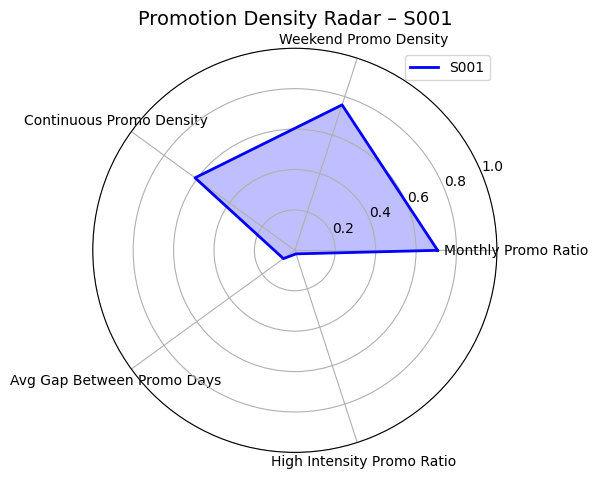

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 将“非促销日平均间隔”标准化（假设最大值为 7 天）
metrics_S001['non_promo_gap_avg'] = round(metrics_S001['non_promo_gap_avg'] / 7, 4)

# 移除缺失值（节假日密度）
metrics_clean = {k: v for k, v in metrics_S001.items() if not np.isnan(v)}

# 设置维度标签（中文注释，但变量为英文）
label_map = {
    'monthly_ratio_avg': 'Monthly Promo Ratio',
    'weekend_ratio': 'Weekend Promo Density',
    'continuous_promo_ratio': 'Continuous Promo Density',
    'non_promo_gap_avg': 'Avg Gap Between Promo Days',
    'high_intensity_ratio': 'High Intensity Promo Ratio'
}

# 获取标签和数值
labels = [label_map[k] for k in metrics_clean.keys()]
values = list(metrics_clean.values())

# 闭合雷达图数据
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# 创建雷达图
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# 绘制数据线条和填充区域
ax.plot(angles, values, color='blue', linewidth=2, label='S001')
ax.fill(angles, values, color='blue', alpha=0.25)

# 设置角度标签和图形样式
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_title('Promotion Density Radar – S001', fontsize=14)
ax.set_ylim(0, 1)
ax.legend(loc='upper right')

# 显示图形
plt.tight_layout()
plt.show()


In [15]:
def classify_promotion_strength(df, ratio_col='Promo_Ratio'):
    """
    根据促销占比划分促销强度等级
    
    参数：
    df : pandas.DataFrame
        包含促销占比的原始数据表
    ratio_col : str
        表示促销占比的列名
    
    返回：
    pandas.DataFrame
        添加 Promotion_Strength_Label 列的新表
    """
    df = df.copy()
    def label_strength(r):
        if r < 0.3:
            return '非促销日'
        elif r < 0.45:
            return '轻促销日'
        elif r < 0.6:
            return '中促销日'
        else:
            return '强促销日'
    
    df['Promotion_Strength_Label'] = df[ratio_col].apply(label_strength)
    return df

In [16]:
stats_labeled = classify_promotion_strength(stats)
print(stats_labeled[['Date', 'Promo_Ratio', 'Promotion_Strength_Label']].head())

        Date  Promo_Ratio Promotion_Strength_Label
0 2022-01-01         0.15                     非促销日
1 2022-01-02         0.20                     非促销日
2 2022-01-03         0.35                     轻促销日
3 2022-01-04         0.45                     中促销日
4 2022-01-05         0.70                     强促销日


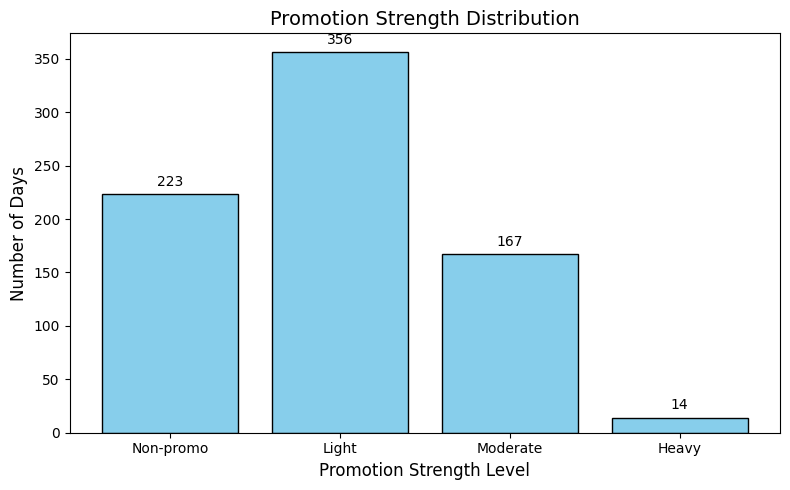

In [18]:
import matplotlib.pyplot as plt

# 统计各促销强度等级的日数分布
strength_counts = stats_labeled['Promotion_Strength_Label'].value_counts().reindex(
    ['非促销日', '轻促销日', '中促销日', '强促销日'], fill_value=0
)

# 设置英文标签映射
label_map = {
    '非促销日': 'Non-promo',
    '轻促销日': 'Light',
    '中促销日': 'Moderate',
    '强促销日': 'Heavy'
}

# 准备绘图数据
labels = [label_map[k] for k in strength_counts.index.tolist()]
values = strength_counts.values.tolist()

# 创建柱状图
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color='skyblue', edgecolor='black')

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, str(height),
            ha='center', va='bottom', fontsize=10)

# 设置英文标题和轴标签
ax.set_title('Promotion Strength Distribution', fontsize=14)
ax.set_ylabel('Number of Days', fontsize=12)
ax.set_xlabel('Promotion Strength Level', fontsize=12)

# 美化布局
plt.tight_layout()
plt.show()

In [20]:
# 筛选出强促销日
strong_days = stats_labeled[stats_labeled['Promotion_Strength_Label'] == '强促销日']

# 提取日期列
strong_dates = strong_days['Date'].sort_values()

# 查看前几行
print(strong_dates)

4     2022-01-05
7     2022-01-08
33    2022-02-03
44    2022-02-14
176   2022-06-26
315   2022-11-12
424   2023-03-01
469   2023-04-15
495   2023-05-11
526   2023-06-11
567   2023-07-22
629   2023-09-22
655   2023-10-18
686   2023-11-18
Name: Date, dtype: datetime64[ns]


In [22]:
# 筛选出中度促销日
moderate_days = stats_labeled[stats_labeled['Promotion_Strength_Label'] == '中促销日']

# 提取日期列并排序
moderate_dates = moderate_days['Date'].sort_values()

# 查看前几行
print(moderate_dates)

3     2022-01-04
16    2022-01-17
17    2022-01-18
21    2022-01-22
31    2022-02-01
         ...    
745   2024-01-16
749   2024-01-20
750   2024-01-21
753   2024-01-24
756   2024-01-27
Name: Date, Length: 167, dtype: datetime64[ns]


## 计算每天的平均折扣率“

In [7]:
df_store_1.head(20)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


In [18]:
import pandas as pd

# 假设 df_store_1 包含以下列：['Date', 'Store', 'Product', 'Discount']

# 1. 按日期分组，计算每天的平均折扣率
daily_avg = df_store_1.groupby('Date')['Discount'].mean().reset_index()
daily_avg.rename(columns={'Discount': 'Avg_Discount'}, inplace=True)

# 2. 生成新的表格，将 Discount 替换为当天的平均值
df_avg = df_store_1[['Date', 'Store ID']].drop_duplicates().merge(
    daily_avg, on='Date', how='left'
)

# 结果：df_avg 每天一行，包含门店、日期和当天平均折扣率
print(df_avg.head())

        Date Store ID  Avg_Discount
0 2022-01-01     S001          5.75
1 2022-01-02     S001          6.75
2 2022-01-03     S001          8.00
3 2022-01-04     S001         10.00
4 2022-01-05     S001         14.75


In [19]:
import pandas as pd

# 假设你的销售数据表为 df_store_1，包含 Discount 列

# 1. 查看所有不同的折扣值
unique_discounts = df_store_1['Discount'].unique()
print("Discount 列的唯一取值：", unique_discounts)

# 2. 查看每个折扣值出现的次数（排序）
discount_counts = df_store_1['Discount'].value_counts().sort_index()
print("Discount 列的取值分布：")
print(discount_counts)

Discount 列的唯一取值： [ 5 15 10  0 25 20]
Discount 列的取值分布：
Discount
0     3494
5     3369
10    4617
15    1267
20    1193
25    1260
Name: count, dtype: int64


In [9]:
import pandas as pd

def build_promotion_matrix(
    coverage_thresholds=(0.30, 0.60),  # 覆盖率阈值：轻促销、中促销、强促销
    discount_thresholds=(0.12, 0.22, 0.30),  # 折扣率阈值：轻促销、中促销、强促销
    labels=('Non-promo', 'Light', 'Moderate', 'Heavy')  # 四类促销日标签
):
    """
    构建一个二维矩阵，表示促销覆盖率与平均折扣率的组合对应的促销等级
    返回一个 pandas DataFrame，行表示折扣率区间，列表示覆盖率区间
    """
    # 初始化矩阵结构
    matrix = pd.DataFrame(index=['<Low', 'Low–Mid', 'Mid–High', '≥High'],
                          columns=['<Low', 'Low–Mid', 'Mid–High', '≥High'])

    # 填充矩阵标签（根据业务逻辑设定）
    matrix.iloc[0, 0] = labels[0]  # 非促销日
    matrix.iloc[1, 0] = labels[1]  # 折扣略高但覆盖低
    matrix.iloc[0, 1] = labels[1]  # 覆盖略高但折扣低
    matrix.iloc[1, 1] = labels[2]  # 折扣和覆盖都中等
    matrix.iloc[2, 2] = labels[2]  # 中促销日
    matrix.iloc[3, 3] = labels[3]  # 强促销日

    # 其他区域默认填 Moderate
    matrix.fillna(labels[2], inplace=True)

    return matrix

In [10]:
# 调用函数，生成促销分类矩阵
promo_matrix = build_promotion_matrix()

# 打印结果
print("Promotion Classification Matrix:")
print(promo_matrix)

Promotion Classification Matrix:
               <Low   Low–Mid  Mid–High     ≥High
<Low      Non-promo     Light  Moderate  Moderate
Low–Mid       Light  Moderate  Moderate  Moderate
Mid–High   Moderate  Moderate  Moderate  Moderate
≥High      Moderate  Moderate  Moderate     Heavy


In [11]:
def classify_promotion_day(df, coverage_col='Promo_Ratio', discount_col='Avg_Discount_Rate'):
    """
    根据促销覆盖率和平均折扣率，将促销日划分为四类：
    - Non-promo: 覆盖率 < 0.30 且 折扣率 < 0.15
    - Light:     覆盖率 < 0.30 且 折扣率 ≥ 0.15
    - Moderate:  覆盖率 ≥ 0.30 且 折扣率 < 0.15
    - Heavy:     覆盖率 ≥ 0.30 且 折扣率 ≥ 0.15
    返回原始 DataFrame，新增一列 Promotion_Level
    """
    df = df.copy()
    cov = df[coverage_col]
    disc = df[discount_col]

    def classify(row):
        if row[coverage_col] < 0.30 and row[discount_col] < 0.15:
            return 'Non-promo'
        elif row[coverage_col] < 0.30 and row[discount_col] >= 0.15:
            return 'Light'
        elif row[coverage_col] >= 0.30 and row[discount_col] < 0.15:
            return 'Moderate'
        else:
            return 'Heavy'

    df['Promotion_Level'] = df.apply(classify, axis=1)
    return df

In [12]:
# 假设 df_daily 包含每天的促销覆盖率和平均折扣率
# 列名为 'Promo_Ratio' 和 'Avg_Discount_Rate'

classified_df = classify_promotion_day(df_daily)

# 查看结果
print(classified_df[['Date', 'Promo_Ratio', 'Avg_Discount_Rate', 'Promotion_Level']].head())


NameError: name 'df_daily' is not defined

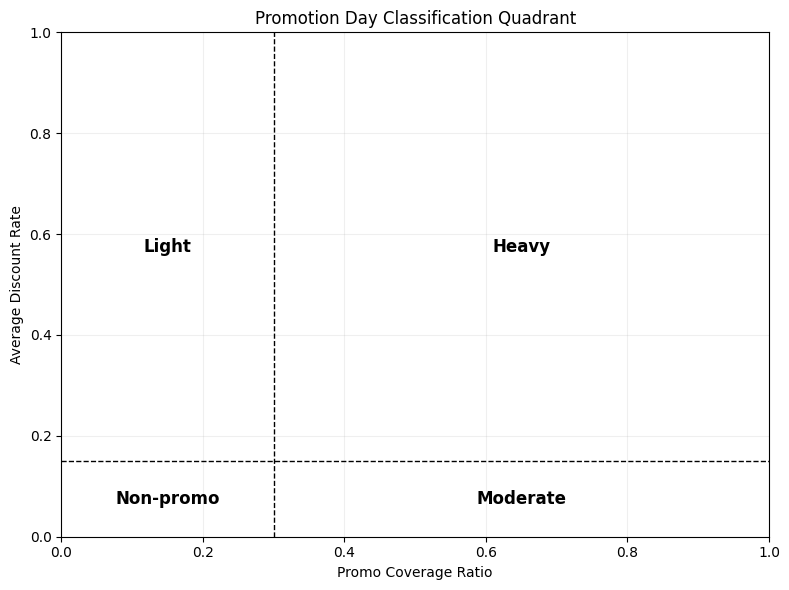

In [2]:
import matplotlib.pyplot as plt

def plot_promotion_quadrant(
    coverage_threshold=0.30,  # 促销覆盖率阈值
    discount_threshold=0.15,  # 平均折扣率阈值
    title='Promotion Day Classification Quadrant'
):
    """
    绘制一个四象限分类图，用于展示促销覆盖率和平均折扣率的划分逻辑
    横轴为覆盖率，纵轴为折扣率，分为四类促销日
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # 绘制阈值线
    ax.axvline(coverage_threshold, color='black', linestyle='--', linewidth=1)
    ax.axhline(discount_threshold, color='black', linestyle='--', linewidth=1)

    # 设置象限标签（英文）
    ax.text(coverage_threshold / 2, discount_threshold / 2, 'Non-promo',
            ha='center', va='center', fontsize=12, weight='bold')
    ax.text(coverage_threshold / 2, (1 + discount_threshold) / 2, 'Light',
            ha='center', va='center', fontsize=12, weight='bold')
    ax.text((1 + coverage_threshold) / 2, discount_threshold / 2, 'Moderate',
            ha='center', va='center', fontsize=12, weight='bold')
    ax.text((1 + coverage_threshold) / 2, (1 + discount_threshold) / 2, 'Heavy',
            ha='center', va='center', fontsize=12, weight='bold')

    # 设置坐标轴范围与标签
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Promo Coverage Ratio')
    ax.set_ylabel('Average Discount Rate')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_promotion_quadrant()


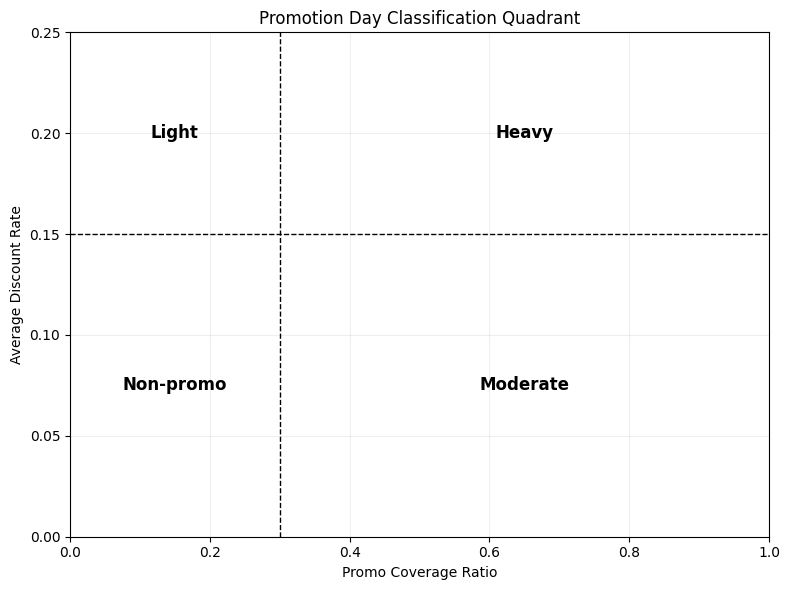

In [1]:
import matplotlib.pyplot as plt

def plot_promotion_quadrant(
    coverage_threshold=0.30,  # 促销覆盖率阈值
    discount_threshold=0.15,  # 平均折扣率阈值
    title='Promotion Day Classification Quadrant'
):
    """
    绘制一个四象限分类图，用于展示促销覆盖率和平均折扣率的划分逻辑
    横轴为覆盖率（0–1），纵轴为折扣率（0–0.25），分为四类促销日
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # 绘制阈值线
    ax.axvline(coverage_threshold, color='black', linestyle='--', linewidth=1)
    ax.axhline(discount_threshold, color='black', linestyle='--', linewidth=1)

    # 设置象限标签（英文）
    ax.text(coverage_threshold / 2, discount_threshold / 2, 'Non-promo',
            ha='center', va='center', fontsize=12, weight='bold')
    ax.text(coverage_threshold / 2, (0.25 + discount_threshold) / 2, 'Light',
            ha='center', va='center', fontsize=12, weight='bold')
    ax.text((1 + coverage_threshold) / 2, discount_threshold / 2, 'Moderate',
            ha='center', va='center', fontsize=12, weight='bold')
    ax.text((1 + coverage_threshold) / 2, (0.25 + discount_threshold) / 2, 'Heavy',
            ha='center', va='center', fontsize=12, weight='bold')

    # 设置坐标轴范围与标签
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.25)
    ax.set_xlabel('Promo Coverage Ratio')
    ax.set_ylabel('Average Discount Rate')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_promotion_quadrant()

In [ ]:
e'u'h